# 任务 2：葡萄酒数据分类实验
本任务以 sklearn 自带的葡萄酒数据集为对象，训练并比较多种分类模型的表现。

示例数据加载：
```Python
from sklearn import datasets
wine = datasets.load_wine()
```

实验要点：

- 探索数据分布与基本统计信息（EDA）
- 使用 `StandardScaler` 对特征做标准化（归一化/标准化）处理
- 构建并比较至少三类模型：逻辑回归、SVM（RBF 核）、决策树
- 使用训练/测试集划分与交叉验证，多次训练取平均结果以降低随机性
- 撰写对比与结论，分析不同模型的优劣与适用场景

## 导入库与环境配置
本单元导入常用数据处理、建模与可视化库，并进行字体与日志配置。
在运行前请确保已安装所需依赖（scikit-learn、pandas、matplotlib 等）。

In [1]:
import os
import sys
import numpy as np  
import pandas as pd 
from pathlib import Path
from loguru import logger
from tqdm.auto import tqdm,trange
from datetime import timedelta,timezone
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from scipy import stats
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['nature', 'vibrant']) # 或者 'ieee', 'nature'
from matplotlib import font_manager

font_path="/home/lanshi/.local/share/fonts/SourceHanSerifSC-Regular.otf"
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['axes.unicode_minus'] = False


logger.remove()

logger.add(
    sink=sys.stderr,
    level="INFO",
    format="<green>{time:YYYY-MM-DD HH:mm:ss.SSS}</green> | "
            "<level>{level:<8}</level> | "
            "<cyan>{name}</cyan>:<cyan>{function}</cyan>:<cyan>{line}</cyan> - "
            "<level>{message}</level>",
    colorize=True
)
logger.info(plt.rcParams['font.family'])
wine = datasets.load_wine()

2026-05-22 22:15:24.503 | INFO     | __main__:<module>:40 - ['Source Han Serif SC']


## 数据探索（EDA）
对特征名、类别分布、缺失值和统计量进行检查，理解数据特性以指导后续预处理与建模。

In [2]:
logger.info(f"x_cols:{wine.feature_names}\n y_labs:{wine.target_names}")  # type: ignore[attr-defined]

2026-05-22 22:15:24.646 | INFO     | __main__:<module>:1 - x_cols:['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
 y_labs:['class_0' 'class_1' 'class_2']


In [3]:
X=pd.DataFrame(data=wine.data,columns=wine.feature_names) # type: ignore[attr-defined]
y=np.array(wine.target)  # type: ignore[attr-defined]
df=X.copy()
df['class']=y


In [4]:
logger.info(f"X shape:{X.shape}\n y shape:{y.shape}")
logger.info(f"X info:{df.drop(columns='class').info()}\n y info:{df['class'].info()}")

2026-05-22 22:15:24.897 | INFO     | __main__:<module>:1 - X shape:(178, 13)
 y shape:(178,)
2026-05-22 22:15:24.901 | INFO     | __main__:<module>:2 - X info:None
 y info:None


<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: float64(13)
m

In [5]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [6]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [7]:
df.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
class                           0
dtype: int64

## 特征标准化（StandardScaler）
将特征缩放为均值为 0、方差为 1 的分布。对基于距离或正则化的模型（如 SVM、LogisticRegression）尤为重要。

In [8]:
scaler = StandardScaler()
df_scaled=df.copy()
df_scaled[df_scaled.columns]=scaler.fit_transform(df[df.columns])

In [9]:
df_scaled.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
count,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,178.000000,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02
mean,-8.382808e-16,-1.197544e-16,-8.370333e-16,-3.991813e-17,-3.991813e-17,0.000000,-3.991813e-16,3.592632e-16,-1.197544e-16,2.494883e-17,1.995907e-16,3.193450e-16,-1.596725e-16,1.596725e-16
std,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00
min,-2.434235e+00,-1.432983e+00,-3.679162e+00,-2.671018e+00,-2.088255e+00,-2.107246,-1.695971e+00,-1.868234e+00,-2.069034e+00,-1.634288e+00,-2.094732e+00,-1.895054e+00,-1.493188e+00,-1.213944e+00
25%,-7.882448e-01,-6.587486e-01,-5.721225e-01,-6.891372e-01,-8.244151e-01,-0.885468,-8.275393e-01,-7.401412e-01,-5.972835e-01,-7.951025e-01,-7.675624e-01,-9.522483e-01,-7.846378e-01,-1.213944e+00
50%,6.099988e-02,-4.231120e-01,-2.382132e-02,1.518295e-03,-1.222817e-01,0.095960,1.061497e-01,-1.760948e-01,-6.289785e-02,-1.592246e-01,3.312687e-02,2.377348e-01,-2.337204e-01,7.996036e-02
75%,8.361286e-01,6.697929e-01,6.981085e-01,6.020883e-01,5.096384e-01,0.808997,8.490851e-01,6.095413e-01,6.291754e-01,4.939560e-01,7.131644e-01,7.885875e-01,7.582494e-01,1.373864e+00
max,2.259772e+00,3.109192e+00,3.156325e+00,3.154511e+00,4.371372e+00,2.539515,3.062832e+00,2.402403e+00,3.485073e+00,3.435432e+00,3.301694e+00,1.960915e+00,2.971473e+00,1.373864e+00


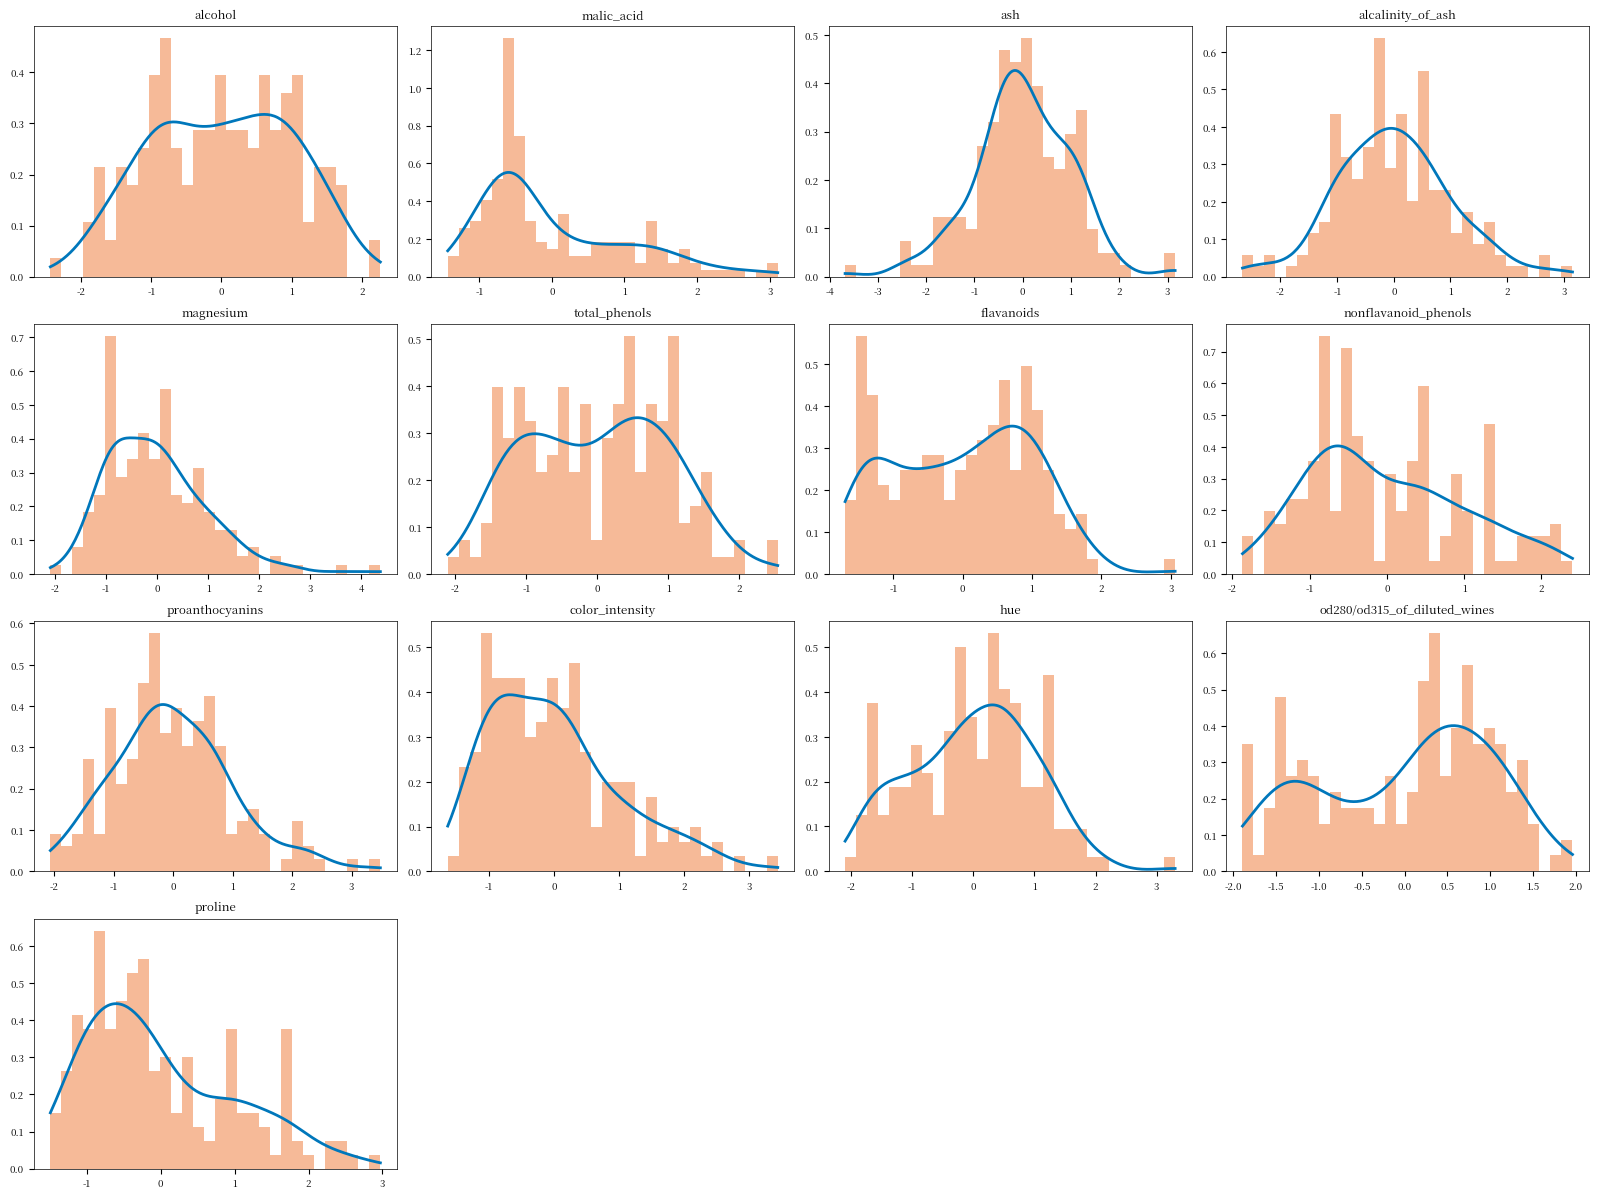

In [10]:
cols = [c for c in df_scaled.columns if c != 'class']
n = len(cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.ravel()

for ax, col in zip(axes, cols):
    data = df_scaled[col].dropna()

    ax.hist(data, bins=30, density=True, color='C0', alpha=0.5)

    kde = stats.gaussian_kde(data)
    xs = np.linspace(data.min(), data.max(), 200)
    ax.plot(xs, kde(xs), color='C1', lw=2)

    ax.set_title(col)

for ax in axes[len(cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig("data/wine.svg")

## 建模与评估流程
使用 `Pipeline` 将预处理与模型组合，方便在交叉验证与最终评估中保持一致的处理流程。
训练时同时记录训练集与测试集准确率，并使用交叉验证评估模型稳健性。

### 逻辑回归（Logistic Regression）
线性分类器，适用于近似线性可分问题。通常需要标准化并采用正则化以防止过拟合。

In [11]:
lr=Pipeline([
    ("scaler",StandardScaler()),
    ("LogisticRegression",LogisticRegression(max_iter=5000,random_state=317))
])

### 支持向量机（SVM，RBF 内核）
基于边界的非线性分类器。对特征缩放敏感，核函数可捕捉复杂决策边界，需调参（C、gamma）。

In [12]:
svm=Pipeline([
    ("scaler",StandardScaler()),
    ("SVC",SVC(kernel='rbf',random_state=42))
])


### 决策树（Decision Tree）
基于规则分裂的模型，对特征缩放不敏感，易解释但容易过拟合，可通过限制深度或叶节点大小进行正则化。

In [13]:
dt=Pipeline([
    ("scaler",StandardScaler()),
    ("DecisionTreeClassifier",DecisionTreeClassifier(random_state=42))
])

In [14]:
models={
    "LogisticRegression":lr,
    "SVC":svm,
    "DecisionTreeClassifier":dt
}
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
cv_res = {}
for name, model in tqdm(models.items()):
    scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    cv_res[name] = scores
    logger.info(name)
    logger.info(f"ac:{scores}")
    logger.info(f"平均准确率: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})\n")


  0%|          | 0/3 [00:00<?, ?it/s]

2026-05-22 22:15:31.686 | INFO     | __main__:<module>:5 - LogisticRegression
2026-05-22 22:15:31.686 | INFO     | __main__:<module>:6 - ac:[0.97222222 0.97222222 1.         0.97142857 1.        ]
2026-05-22 22:15:31.686 | INFO     | __main__:<module>:7 - 平均准确率: 0.9832 (+/- 0.0275)

2026-05-22 22:15:31.699 | INFO     | __main__:<module>:5 - SVC
2026-05-22 22:15:31.699 | INFO     | __main__:<module>:6 - ac:[1.         0.97222222 0.94444444 1.         1.        ]
2026-05-22 22:15:31.700 | INFO     | __main__:<module>:7 - 平均准确率: 0.9833 (+/- 0.0444)

2026-05-22 22:15:31.712 | INFO     | __main__:<module>:5 - DecisionTreeClassifier
2026-05-22 22:15:31.712 | INFO     | __main__:<module>:6 - ac:[0.91666667 0.80555556 0.83333333 0.91428571 0.85714286]
2026-05-22 22:15:31.713 | INFO     | __main__:<module>:7 - 平均准确率: 0.8654 (+/- 0.0881)



In [16]:
res={}
for name,model in tqdm(models.items()):
    model.fit(X_train,y_train)
    train_score=model.score(X_train,y_train)
    test_score=model.score(X_test,y_test)
    logger.info(f"训练集分数:{train_score}")
    logger.info(f"测试集分数:{test_score}")
    res[name]={
        'train': train_score,
        'test': test_score
    }
    logger.info(f"{name:25s} | Train Acc: {train_score:.4f} | Test Acc: {test_score:.4f}")


  0%|          | 0/3 [00:00<?, ?it/s]

2026-05-22 22:15:31.967 | INFO     | __main__:<module>:6 - 训练集分数:1.0
2026-05-22 22:15:31.967 | INFO     | __main__:<module>:7 - 测试集分数:0.9722222222222222
2026-05-22 22:15:31.968 | INFO     | __main__:<module>:12 - LogisticRegression        | Train Acc: 1.0000 | Test Acc: 0.9722
2026-05-22 22:15:31.971 | INFO     | __main__:<module>:6 - 训练集分数:0.9929577464788732
2026-05-22 22:15:31.972 | INFO     | __main__:<module>:7 - 测试集分数:0.9722222222222222
2026-05-22 22:15:31.972 | INFO     | __main__:<module>:12 - SVC                       | Train Acc: 0.9930 | Test Acc: 0.9722
2026-05-22 22:15:31.975 | INFO     | __main__:<module>:6 - 训练集分数:1.0
2026-05-22 22:15:31.975 | INFO     | __main__:<module>:7 - 测试集分数:0.9444444444444444
2026-05-22 22:15:31.975 | INFO     | __main__:<module>:12 - DecisionTreeClassifier    | Train Acc: 1.0000 | Test Acc: 0.9444


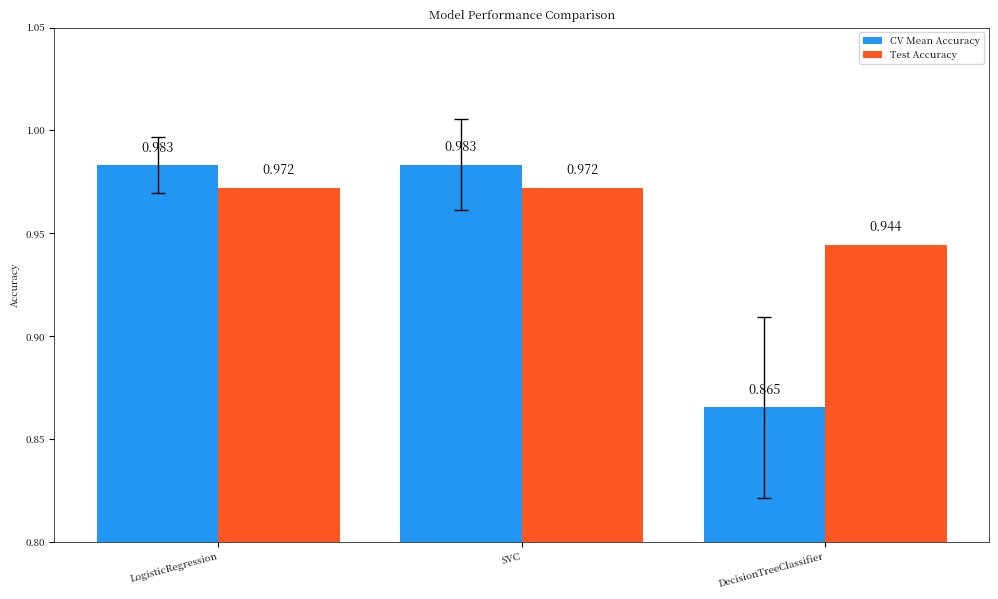

In [18]:
model_names = list(res.keys())
cv_means = [cv_res[name].mean() for name in model_names]
cv_stds = [cv_res[name].std() for name in model_names]
test_scores = [res[name]['test'] for name in model_names]

x_pos = np.arange(len(model_names))

fig, ax = plt.subplots(figsize=(10, 6))

# 绘制交叉验证准确率
bars_cv = ax.bar(x_pos - 0.2, cv_means, 0.4, label='CV Mean Accuracy', color='#2196F3', yerr=cv_stds, capsize=5)
# 绘制测试集准确率
bars_test = ax.bar(x_pos + 0.2, test_scores, 0.4, label='Test Accuracy', color='#FF5722')

ax.set_ylabel('Accuracy')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.legend()
ax.set_ylim(0.8, 1.05) # 调整Y轴范围以便更清晰看到差异

# 添加数值标签
for bar in bars_cv:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)

for bar in bars_test:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("data/model_comparison.svg", bbox_inches='tight')

### 思考总结

- **Logistic Regression**：稳定且可解释，适合线性或近似线性问题；对特征尺度敏感，需标准化并常配合正则化使用。

- **SVM (RBF)**：在中小规模数据集上表现好，能捕捉非线性边界；高度依赖标准化，需调参（C、gamma）以获得最佳性能。

- **Decision Tree**：对特征缩放不敏感，易解释但易过拟合；通过限制 `max_depth`、`min_samples_leaf` 或使用集成方法（随机森林、GBDT）可有效提升泛化能力。

建议：

- 对基于距离或正则化的模型（LR、SVM）务必进行标准化；
- 使用交叉验证与多次重复实验来获得稳健的性能估计；
- 若关注泛化性能，优先考虑集成方法或对复杂模型做更严格的正则化与调参；
- 使用混淆矩阵、ROC/PR 曲线等指标对模型进行更全面的评价。